## EDA

### Load Data

In [48]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

# Read raw data
master_dir = os.path.dirname(os.getcwd())

cleaned_reviews = os.path.join(master_dir, "data", "cleaned_data", "cleaned_reviews.csv")
ori_reviews = os.path.join(master_dir, "data", "raw_data", "combined_reviews.csv")

df_original = pd.read_csv(
    ori_reviews,
    dtype={"Title": "string", "Dates": "string"},
)
df_cleaned = pd.read_csv(cleaned_reviews)

### Dataset Overview

In [49]:
print("Original:", len(df_original))
print("Cleaned:", len(df_cleaned))
print("Removed:", len(df_original) - len(df_cleaned))

Original: 371116
Cleaned: 96612
Removed: 274504


### Distribution across different location in Original Dataset

In [50]:
df_original["Location"].value_counts()

Location
KL               99240
Petaling Jaya    51464
Penang           45730
JB               36261
Ipoh             32437
Kuching          30852
Langkawi         30575
Melaka           27029
Miri              8836
Shah Alam         8692
Name: count, dtype: int64

<Axes: title={'center': 'Review Distribution'}, xlabel='Location', ylabel='No. of reviews'>

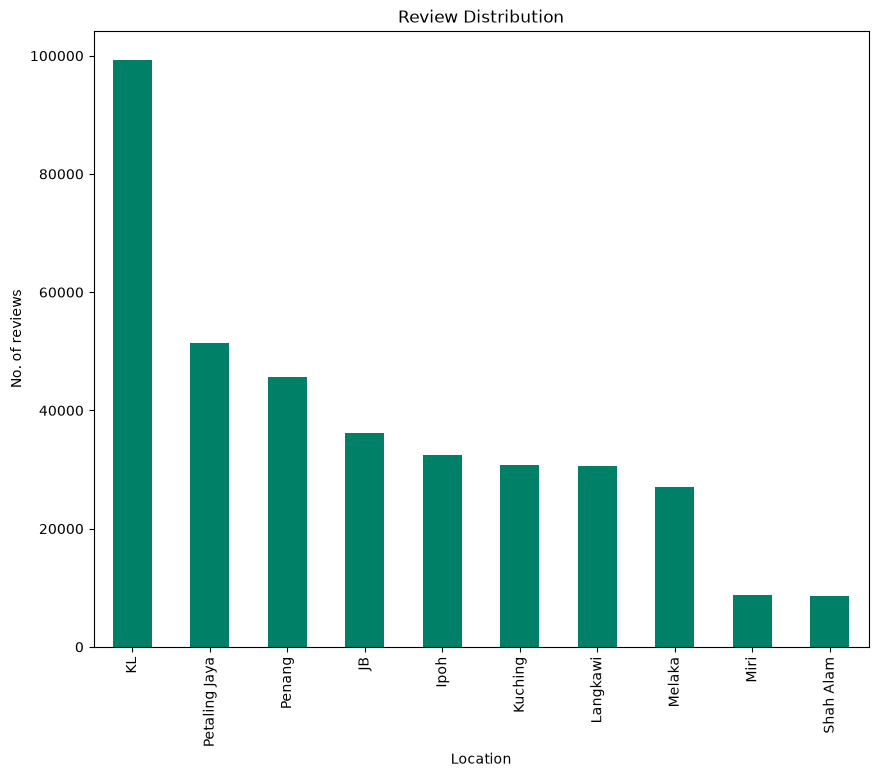

In [51]:
df_original["Location"].value_counts().plot(kind='bar',
                                       figsize=(10, 8),
                                       ylabel="No. of reviews",
                                       title="Review Distribution",
                                       cmap='summer',
                                      )

Highest on review on Kuala Lumpur, lowest on Miri

### Distribution of Platforms in Original Dataset

<Axes: title={'center': 'Distribution of Platforms in Original Dataset'}, xlabel='Platform'>

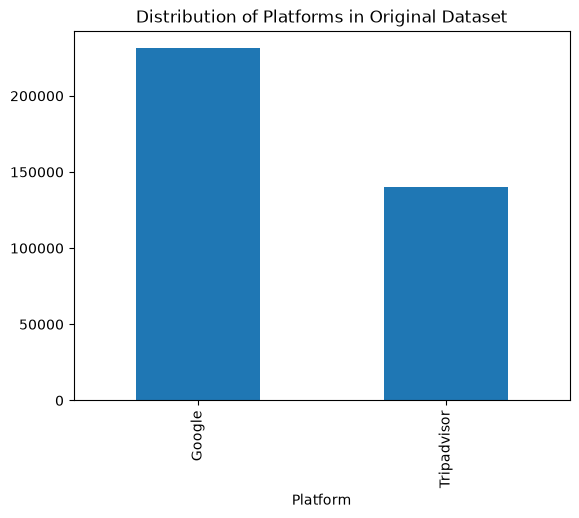

In [52]:
# Compare the distribution of platforms in the original and cleaned datasets
df_original["Platform"].value_counts().plot(kind='bar', title='Distribution of Platforms in Original Dataset')

Google has more reviews compared to TripAdvisor

### Distribution of Ratings in Cleaned Dataset

In [53]:
df_cleaned["Rating"].isna().sum()

np.int64(0)

<Axes: title={'center': 'Distribution of Ratings in Cleaned Dataset'}, xlabel='Rating'>

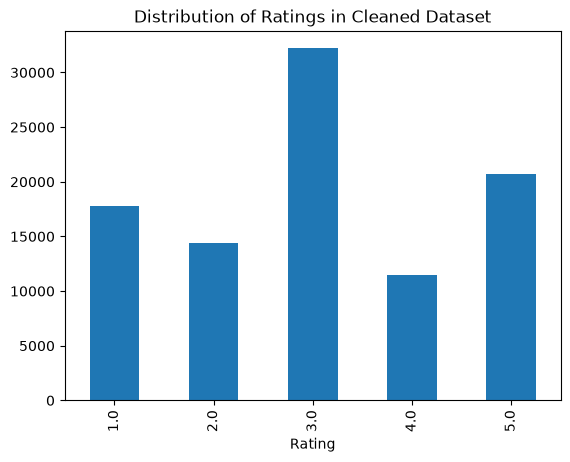

In [54]:
# Rating distribution in the cleaned dataset
df_cleaned["Rating"].value_counts().sort_index().plot(kind='bar', title='Distribution of Ratings in Cleaned Dataset')

In [55]:
# average rating in the cleaned dataset
avgRating = df_original["Rating"].astype(float).mean()

avgRating

np.float64(4.178696148913009)

most of the ratings is high as the average rating is around 4.18

### Top Restaurant in Original Dataset

In [56]:
averageRating_restaurants = df_original[["Restaurant", "Rating"]] \
                .pivot_table(index=['Restaurant'], values='Rating', aggfunc='mean') \
                .sort_values('Rating', ascending=False)
averageRating_restaurants.head(10)

,Rating
Restaurant,
362 Gunung Rapat Heong Peah,5.0
Kim Treasure,5.0
Kee Hiong Bak Kut Teh,5.0
Kedai Makan Leong Heng,5.0
Zest Restaurant at Miri Marriott Resort & Spa,5.0
Teck Teh Bakuteh,5.0
Tea & Toast,5.0
Canard eat & roll,5.0
Suka Kafe,5.0


many restaurant got 5.0 rating which is not relect the real scenario because some restaurant with high rating may have very less review

In [57]:
# Average rating for each restaurant
averageRating_restaurants = (
    df_original.groupby("Restaurant")["Rating"]
    .mean()
    .reset_index(name="Average Rating")
)

# Number of reviews for each restaurant
restaurant_reviewcount = (
    df_original.groupby("Restaurant")
    .size()
    .reset_index(name="Review Count")
)

In [58]:
overall_toprestaurants = (
    averageRating_restaurants
    .merge(restaurant_reviewcount, on="Restaurant")
    .sort_values(
        by=["Review Count", "Average Rating"],
        ascending=False
    )
    .head(10)
)

overall_toprestaurants

,Restaurant,Average Rating,Review Count
677,Dining In The Dark KL,4.672108,2083
1183,Ishin Japanese Dining,4.463684,2079
1342,Khan’s Indian Cuisine,4.428949,1893
1014,Hard Rock Cafe,3.826692,1581
3374,Wonderland Food Store,4.403743,1496
887,Geographer Cafe,3.753274,1451
218,BBQ NIGHTS,4.398628,1312
3162,The Whisky Bar,4.735202,1284
426,Canopy Rooftop Bar and Lounge,4.880126,1268
1605,Madam Kwan's KLCC,3.843849,1268


In [59]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=overall_toprestaurants['Restaurant'], 
               y=overall_toprestaurants['Average Rating'], name="Rating", mode="lines"),
    secondary_y=True
)

fig.add_trace(
    go.Bar(x=overall_toprestaurants['Restaurant'],
           y=overall_toprestaurants['Review Count'], name="Review Count"),
    secondary_y=False
)

fig.update_xaxes(title_text="Review Count")

# Set y-axes titles
fig.update_yaxes(title_text="Review Count", secondary_y=False)
fig.update_yaxes(title_text="Rating", secondary_y=True)

fig.show()

### Average rating across different locations in Original Dataset

<Axes: title={'center': 'Rating Distribution'}, xlabel='Location', ylabel='Average Rating'>

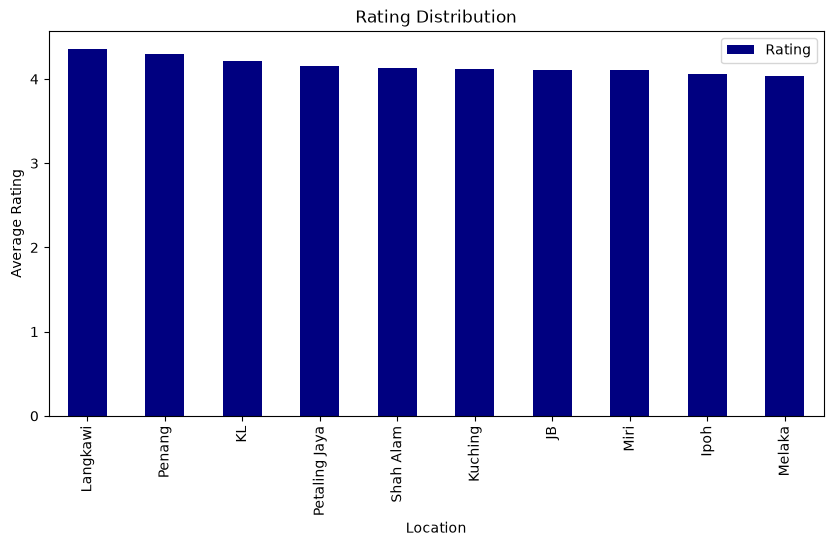

In [60]:
# Average rating across different locations

df_original.pivot_table(index='Location', values='Rating', aggfunc='mean') \
    .sort_values('Rating', ascending=False) \
    .plot(kind='bar', ylabel="Average Rating",
          title="Rating Distribution", figsize=(10, 5), cmap='jet'
         )

### Distribution of Ratings for Google Reviews in Cleaned Dataset

<Axes: title={'center': 'Distribution of Ratings for Google Reviews in Cleaned Dataset'}, xlabel='Rating'>

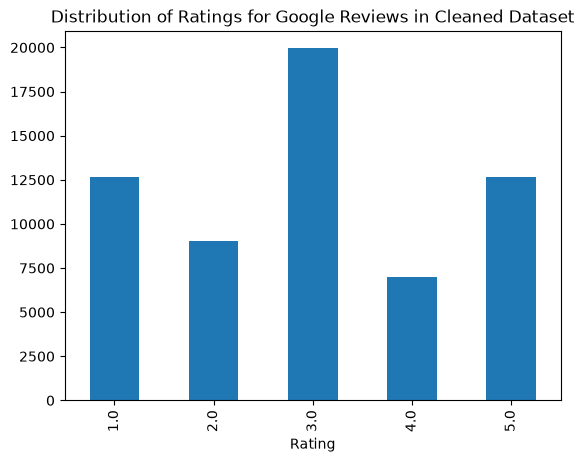

In [61]:
# Rating distribution for Google Reviews in the cleaned dataset
df_cleaned[df_cleaned["Platform"] == "Google"]["Rating"].value_counts().sort_index().plot(kind='bar', title='Distribution of Ratings for Google Reviews in Cleaned Dataset')

### Distribution of Ratings for TripAdvisor Reviews in Cleaned Dataset

<Axes: title={'center': 'Distribution of Ratings for TripAdvisor Reviews in Cleaned Dataset'}, xlabel='Rating'>

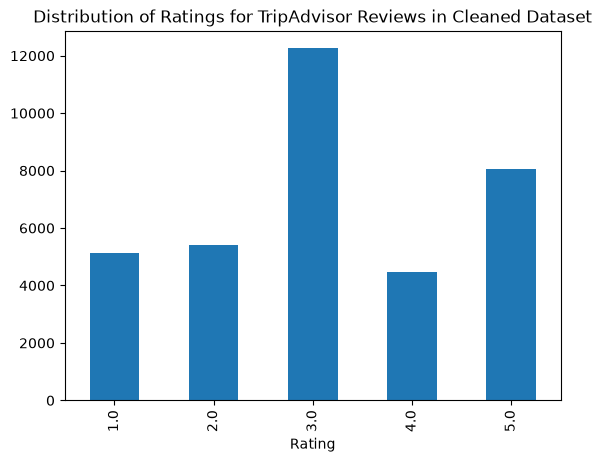

In [62]:
# Rating distribution for TripAdvisor Reviews in the cleaned dataset
df_cleaned[df_cleaned["Platform"] == "Tripadvisor"]["Rating"].value_counts().sort_index().plot(kind='bar', title='Distribution of Ratings for TripAdvisor Reviews in Cleaned Dataset')

### Average Ratings for each Platforms in Cleaned Dataset

In [63]:
# Average rating for each platform in the cleaned dataset
average_ratings = df_cleaned.groupby("Platform")["Rating"].mean()

average_ratings

Platform
Google         2.967179
Tripadvisor    3.140347
Name: Rating, dtype: float64

The average rating for TripAdvisor review is higher

### Review Length Analysis

In [64]:
# Review length in characters
df_cleaned["Review_Length"] = df_cleaned["Review"].str.len()

# Review length in words
df_cleaned["Word_Count"] = df_cleaned["Review"].str.split().str.len()

df_cleaned[["Review_Length", "Word_Count"]].describe()

,Review_Length,Word_Count
count,96612.000000,96612.000000
mean,305.657558,54.947222
std,371.273453,67.831123
min,1.000000,1.000000
25%,72.000000,12.000000
50%,177.000000,31.000000
75%,403.000000,72.000000
max,9343.000000,1531.000000


C:\Users\user\AppData\Local\Temp\ipykernel_3196\3894073128.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_cleaned["Word_Count"], vert=False)


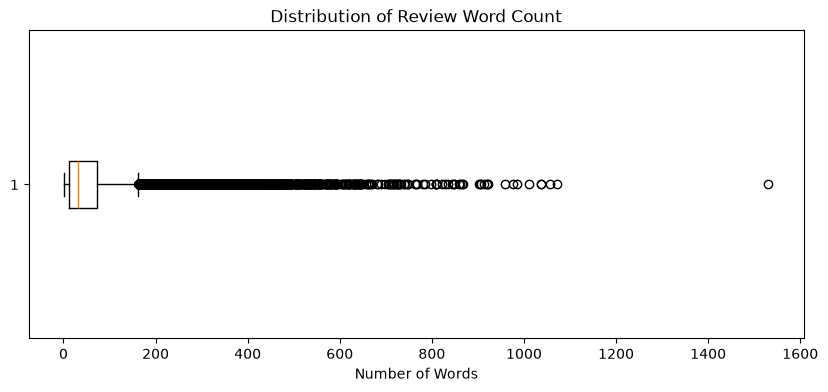

In [65]:
import matplotlib.pyplot as plt

# see the distribution of review word count in the cleaned dataset
plt.figure(figsize=(10, 4))

plt.boxplot(df_cleaned["Word_Count"], vert=False)

plt.xlabel("Number of Words")
plt.title("Distribution of Review Word Count")

plt.show()

<Figure size 800x500 with 0 Axes>

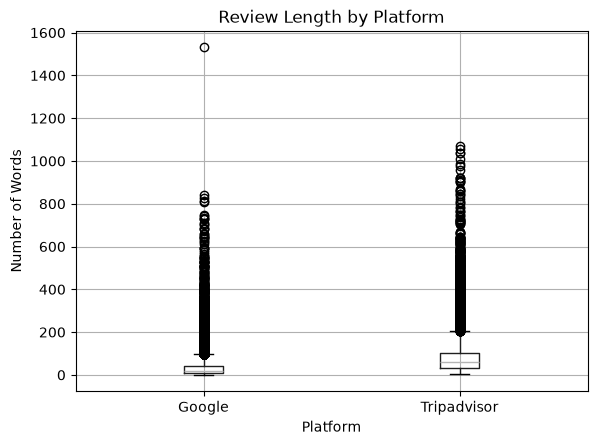

In [66]:
# compare review length by platform
plt.figure(figsize=(8, 5))

df_cleaned.boxplot(
    column="Word_Count",
    by="Platform"
)

plt.title("Review Length by Platform")
plt.suptitle("")
plt.xlabel("Platform")
plt.ylabel("Number of Words")

plt.show()

### Word Frequency

In [67]:
from collections import Counter
import ast

df_cleaned["Lemmatized_Tokens"] = df_cleaned["Lemmatized_Tokens"].apply(
    ast.literal_eval
)

all_lemmas = []

for tokens in df_cleaned["Lemmatized_Tokens"]:
    all_lemmas.extend(
        token.lower()
        for token in tokens
        if token.isalpha()
    )

word_freq = Counter(all_lemmas)

word_freq_df = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

word_freq_df

,Word,Frequency
0,not,85328
1,food,72110
2,but,49199
3,good,44471
4,very,30696
5,service,29544
6,place,26677
7,restaurant,25629
8,so,25548
9,less,25139


In [68]:
platform_word_freq = {}

# get the word frequency for each platform
for platform in df_cleaned["Platform"].unique():
    
    tokens = []
    
    platform_reviews = df_cleaned[
        df_cleaned["Platform"] == platform
    ]["Lemmatized_Tokens"]
    
    for review_tokens in platform_reviews:
        tokens.extend(
            token.lower()
            for token in review_tokens
            if token.isalpha()
        )
    
    platform_word_freq[platform] = Counter(tokens)

In [69]:
# Display the top 15 words for each platform
for platform, freq in platform_word_freq.items():
    
    print(f"\nTop words - {platform}")
    
    for word, count in freq.most_common(15):
        print(f"{word}: {count}")


Top words - Google
not: 43120
food: 39806
but: 24398
good: 23757
service: 15601
very: 15179
place: 13198
taste: 12395
so: 11997
price: 11637
order: 11384
restaurant: 10047
nice: 9938
come: 8573
time: 8182

Top words - Tripadvisor
not: 42208
food: 32304
but: 24801
less: 24060
good: 20714
restaurant: 15582
very: 15517
service: 13943
so: 13551
place: 13479
order: 12179
go: 11553
come: 10092
show: 9440
staff: 9259


### WordCloud

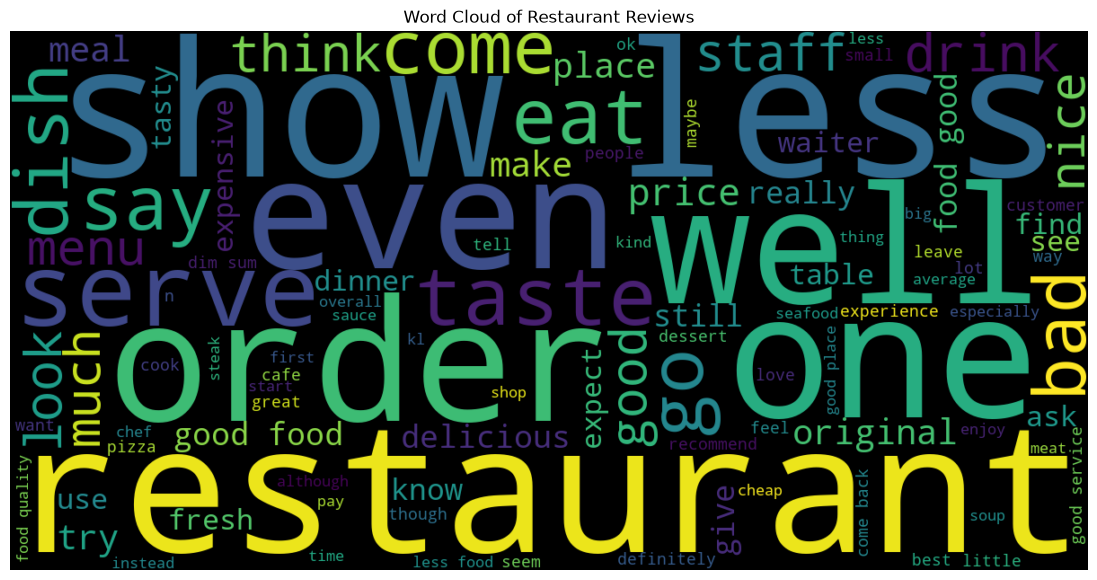

In [70]:
from wordcloud import WordCloud

# Generate a word cloud from the lemmatized tokens
text_for_wordcloud = " ".join(all_lemmas)

wordcloud = WordCloud(
    width=1200,
    height=600,
    max_words=100
).generate(text_for_wordcloud)

plt.figure(figsize=(14, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("Word Cloud of Restaurant Reviews")

plt.show()

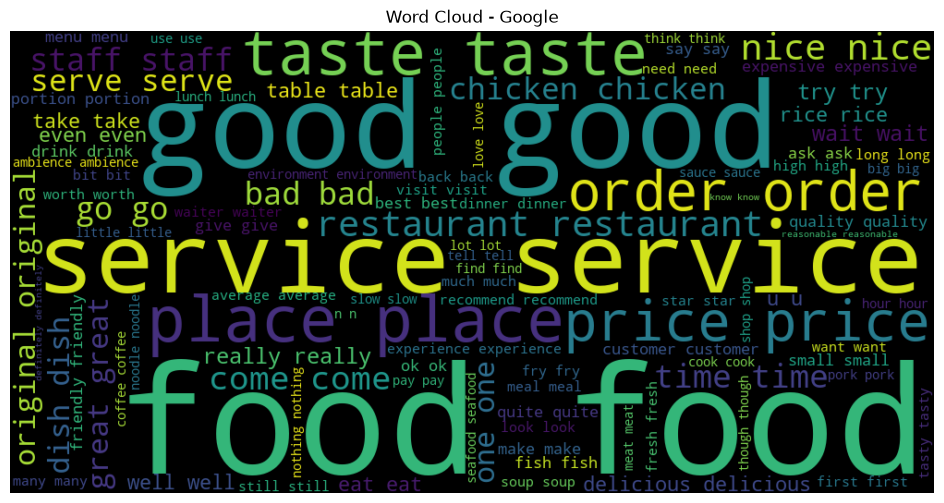

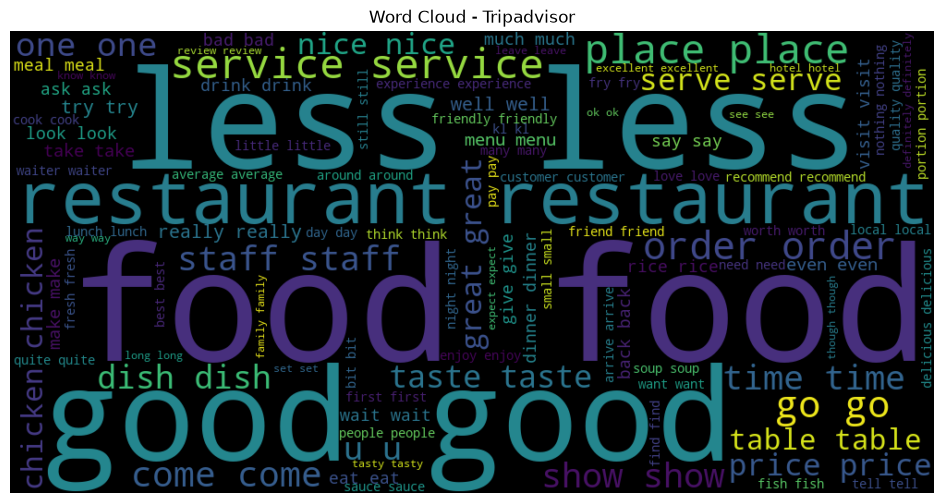

In [71]:
# Word Cloud for each platform

for platform, freq in platform_word_freq.items():
    
    text = " ".join(
        word for word, count in freq.items()
        for _ in range(count)
    )
    
    wordcloud = WordCloud(
        width=1000,
        height=500,
        max_words=100
    ).generate(text)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud - {platform}")
    plt.show()

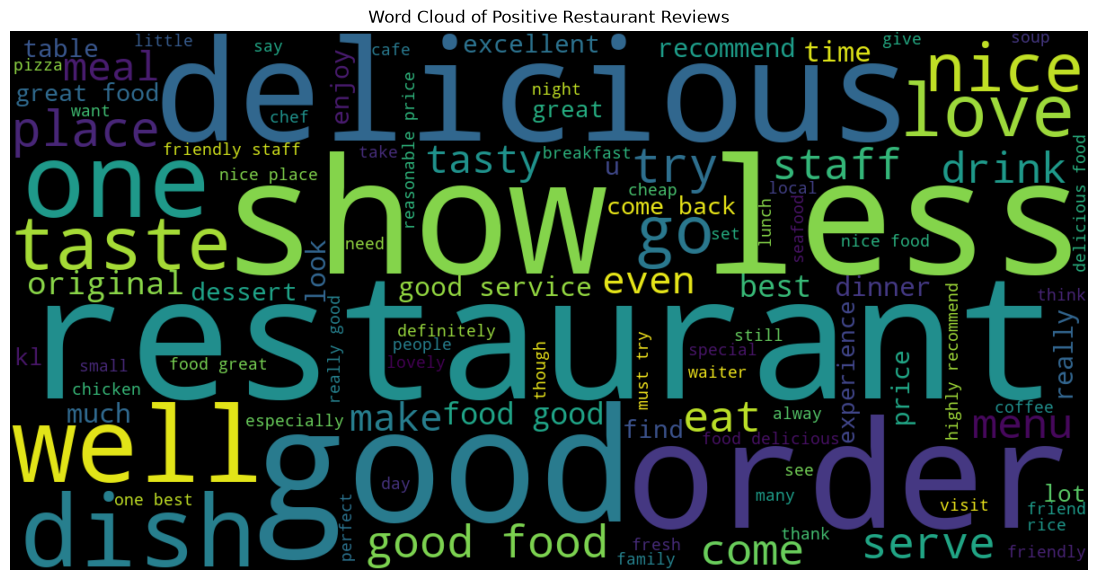

In [72]:
# Word Cloud for ratings > 3, which are considered positive reviews

all_positive_tokens = []

for tokens in df_cleaned["Lemmatized_Tokens"] [df_cleaned["Rating"] > 3]:
    all_positive_tokens.extend(
        token.lower()
        for token in tokens
        if token.isalpha()
    )

text_for_wordcloud = " ".join(all_positive_tokens)

wordcloud = WordCloud(
    width=1200,
    height=600,
    max_words=100
).generate(text_for_wordcloud)

plt.figure(figsize=(14, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("Word Cloud of Positive Restaurant Reviews")

plt.show()

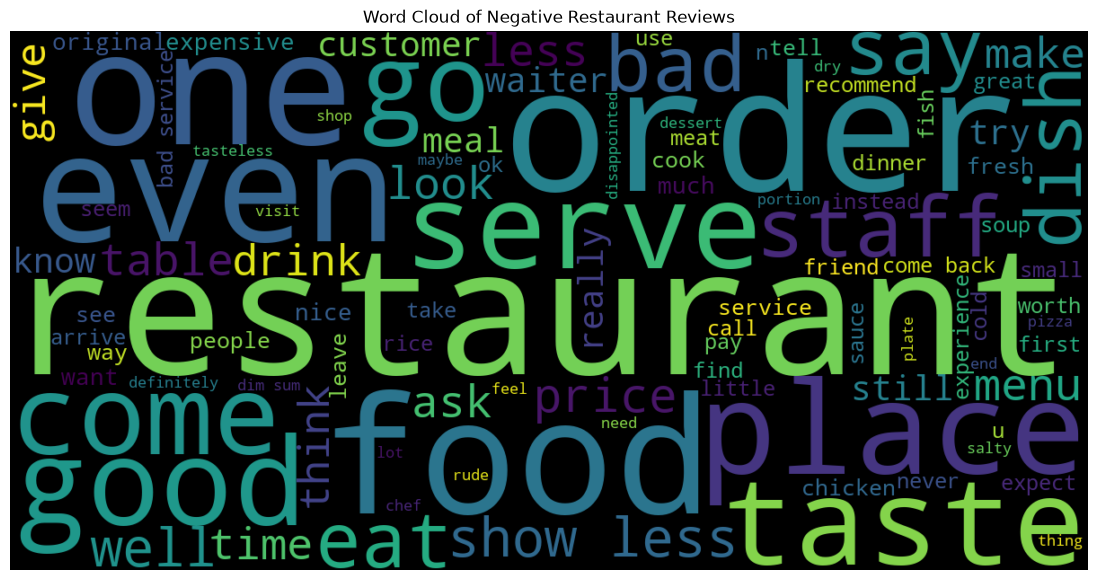

In [73]:
# Word Cloud for ratings < 3, which are considered negative reviews

all_negative_tokens = []

for tokens in df_cleaned["Lemmatized_Tokens"] [df_cleaned["Rating"] < 3]:
    all_negative_tokens.extend(
        token.lower()
        for token in tokens
        if token.isalpha()
    )

text_for_wordcloud = " ".join(all_negative_tokens)

wordcloud = WordCloud(
    width=1200,
    height=600,
    max_words=100
).generate(text_for_wordcloud)

plt.figure(figsize=(14, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")
plt.title("Word Cloud of Negative Restaurant Reviews")

plt.show()

### Bigrams Analysis

In [74]:
from nltk.util import ngrams
from collections import Counter

# Create a Counter to hold the bigram frequencies
bigram_freq = Counter()

for tokens in df_cleaned["Lemmatized_Tokens"]:
    
    clean_tokens = [
        token.lower()
        for token in tokens
        if token.isalpha()
    ]
    
    bigrams = ngrams(clean_tokens, 2)
    
    bigram_freq.update(bigrams)

bigram_df = pd.DataFrame(
    [
        (" ".join(bigram), count)
        for bigram, count in bigram_freq.most_common(20)
    ],
    columns=["Bigram", "Frequency"]
)

bigram_df

,Bigram,Frequency
0,show less,8487
1,but not,5375
2,food not,4079
3,good food,3504
4,food good,3237
5,good but,3215
6,very good,3008
7,dim sum,2601
8,come back,2591
9,not worth,2531


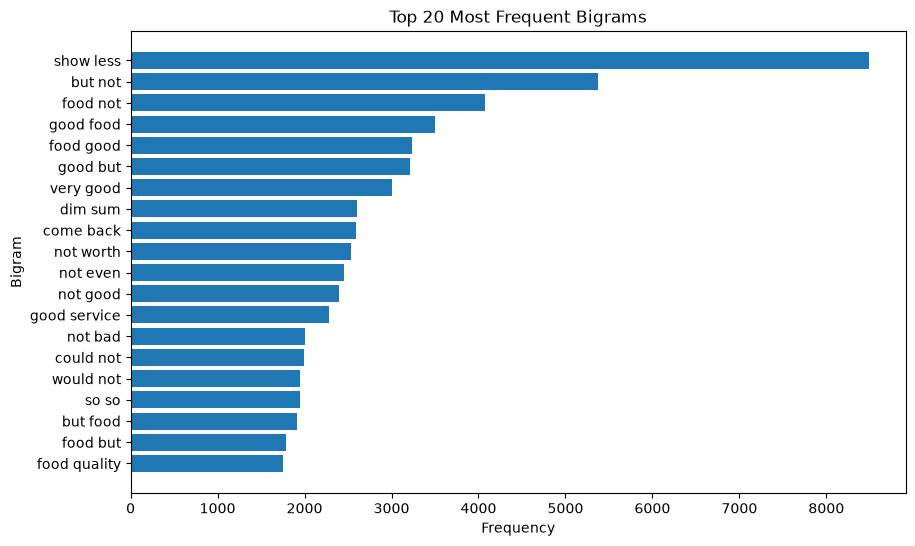

In [75]:
# Visualize the top 20 most frequent bigrams    
plt.figure(figsize=(10, 6))

plt.barh(
    bigram_df["Bigram"][::-1],
    bigram_df["Frequency"][::-1]
)

plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 20 Most Frequent Bigrams")

plt.show()

In [76]:
# Bigram frequency distribution for positive reviews
positive_reviews_bigram_freq = Counter()

for tokens in df_cleaned["Lemmatized_Tokens"] [df_cleaned["Rating"] > 3]:
    
    clean_tokens = [
        token.lower()
        for token in tokens
        if token.isalpha()
    ]
    
    bigrams = ngrams(clean_tokens, 2)
    
    positive_reviews_bigram_freq.update(bigrams)

bigram_df = pd.DataFrame(
    [
        (" ".join(bigram), count)
        for bigram, count in positive_reviews_bigram_freq.most_common(20)
    ],
    columns=["Bigram", "Frequency"]
)

bigram_df

,Bigram,Frequency
0,show less,3004
1,good food,1794
2,very good,1756
3,food good,1295
4,good service,1208
5,very nice,985
6,great food,962
7,come back,941
8,very friendly,908
9,friendly staff,875


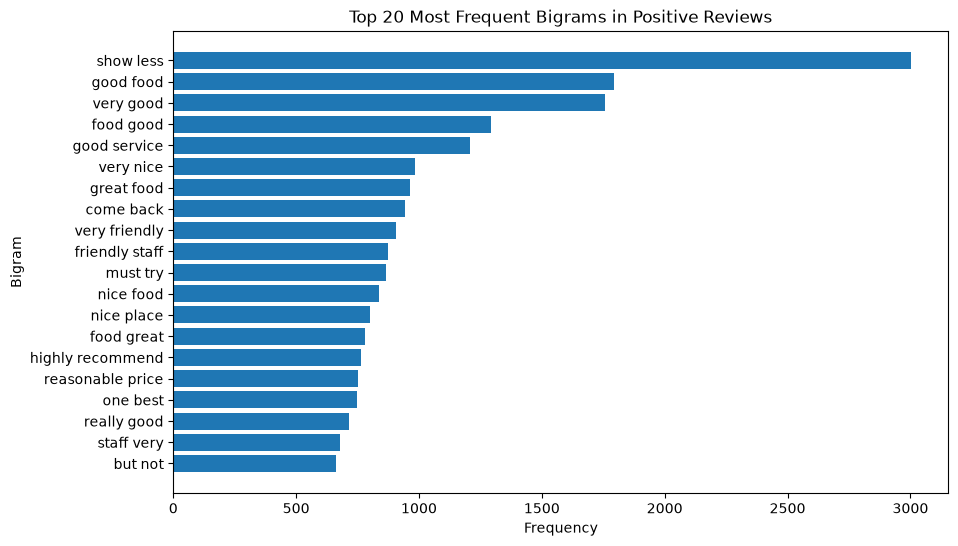

In [77]:
# Visualize the top 20 most frequent bigrams in positive reviews  
plt.figure(figsize=(10, 6))

plt.barh(
    bigram_df["Bigram"][::-1],
    bigram_df["Frequency"][::-1]
)

plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 20 Most Frequent Bigrams in Positive Reviews")

plt.show()

In [78]:
# Bigram frequency distribution for negative reviews
negative_reviews_bigram_freq = Counter()

for tokens in df_cleaned["Lemmatized_Tokens"] [df_cleaned["Rating"] < 3]:
    
    clean_tokens = [
        token.lower()
        for token in tokens
        if token.isalpha()
    ]
    
    bigrams = ngrams(clean_tokens, 2)
    
    negative_reviews_bigram_freq.update(bigrams)

bigram_df = pd.DataFrame(
    [
        (" ".join(bigram), count)
        for bigram, count in negative_reviews_bigram_freq.most_common(20)
    ],
    columns=["Bigram", "Frequency"]
)

bigram_df

,Bigram,Frequency
0,show less,2971
1,food not,2440
2,but not,2231
3,not even,2009
4,not worth,1995
5,not good,1437
6,not recommend,1407
7,bad service,1182
8,would not,1174
9,could not,1146


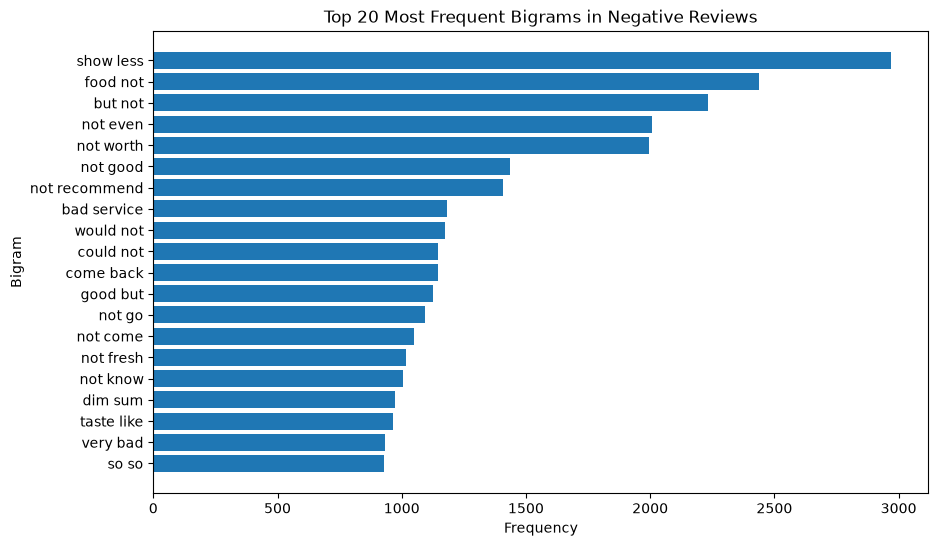

In [79]:
# Visualize the top 20 most frequent bigrams in negative reviews  
plt.figure(figsize=(10, 6))

plt.barh(
    bigram_df["Bigram"][::-1],
    bigram_df["Frequency"][::-1]
)

plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 20 Most Frequent Bigrams in Negative Reviews")

plt.show()

### POS tagging

In [80]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")

# get the tokens for each review in the cleaned dataset
df_cleaned["Tokens"] = df_cleaned["Review"].apply(word_tokenize)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [81]:
nltk.download("averaged_perceptron_tagger_eng")

from nltk import pos_tag

# get the POS tags for each review in the cleaned dataset
df_cleaned["POS_Tags"] = df_cleaned["Tokens"].apply(pos_tag)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [82]:
# create a function to categorize POS tags into broader categories
def get_pos_category(tag):
    if tag.startswith("N"):
        return "Noun"
    elif tag.startswith("J"):
        return "Adjective"
    elif tag.startswith("V"):
        return "Verb"
    elif tag.startswith("R"):
        return "Adverb"
    else:
        return "Other"

In [83]:
from collections import Counter

pos_counts = Counter()

for tagged_tokens in df_cleaned["POS_Tags"]:
    for word, tag in tagged_tokens:
        category = get_pos_category(tag)
        pos_counts[category] += 1

pos_df = pd.DataFrame(
    pos_counts.items(),
    columns=["POS Category", "Frequency"]
).sort_values(
    "Frequency",
    ascending=False
)

pos_df

,POS Category,Frequency
4,Other,2484204
0,Noun,1404534
1,Verb,961146
3,Adjective,643558
2,Adverb,481622


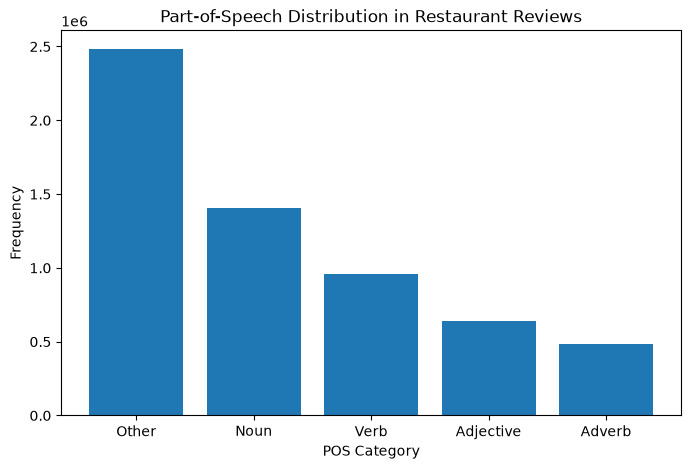

In [84]:
# Visualize the POS distribution in the original dataset
plt.figure(figsize=(8, 5))

plt.bar(
    pos_df["POS Category"],
    pos_df["Frequency"]
)

plt.xlabel("POS Category")
plt.ylabel("Frequency")
plt.title("Part-of-Speech Distribution in Restaurant Reviews")

plt.show()